In [37]:
#披萨销量预测____自动ARIMA模型
#基于2023年1月1日到2023年12月31日的日销量数据，
#预测2024年1月1日到1月28日的每日总销量（4周）。
import pandas as pd
import numpy as np
import warnings
import pmdarima as pm
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

#导入数据
file_path = r"C:\Users\LHN\Desktop\披萨销量预测项目\披萨销售明细数据.xlsx"
df = pd.read_excel(file_path)

print("数据行数:", len(df))
print("日期范围:", df['order_date'].min(), "----", df['order_date'].max())

#汇总销量
df['date']=pd.to_datetime(df['order_date']).dt.date

daily_sales = df.groupby('date')['quantity'].sum().reset_index()
daily_sales.columns = ['date', 'total_quantity']
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

full_date_range = pd.date_range(start=daily_sales['date'].min(), 
                                end=daily_sales['date'].max(), freq='D')
daily_sales = daily_sales.set_index('date').reindex(full_date_range, fill_value=0)
daily_sales.index.name = 'date'
daily_sales = daily_sales.reset_index()
daily_sales.columns = ['date', 'total_quantity']

print("数据总天数:", len(daily_sales))

#时间序列分析
series = daily_sales['total_quantity'].values
dates = daily_sales['date']


数据行数: 48620
日期范围: 2023-01-01 00:00:00 ---- 2023-12-31 00:00:00
数据总天数: 365


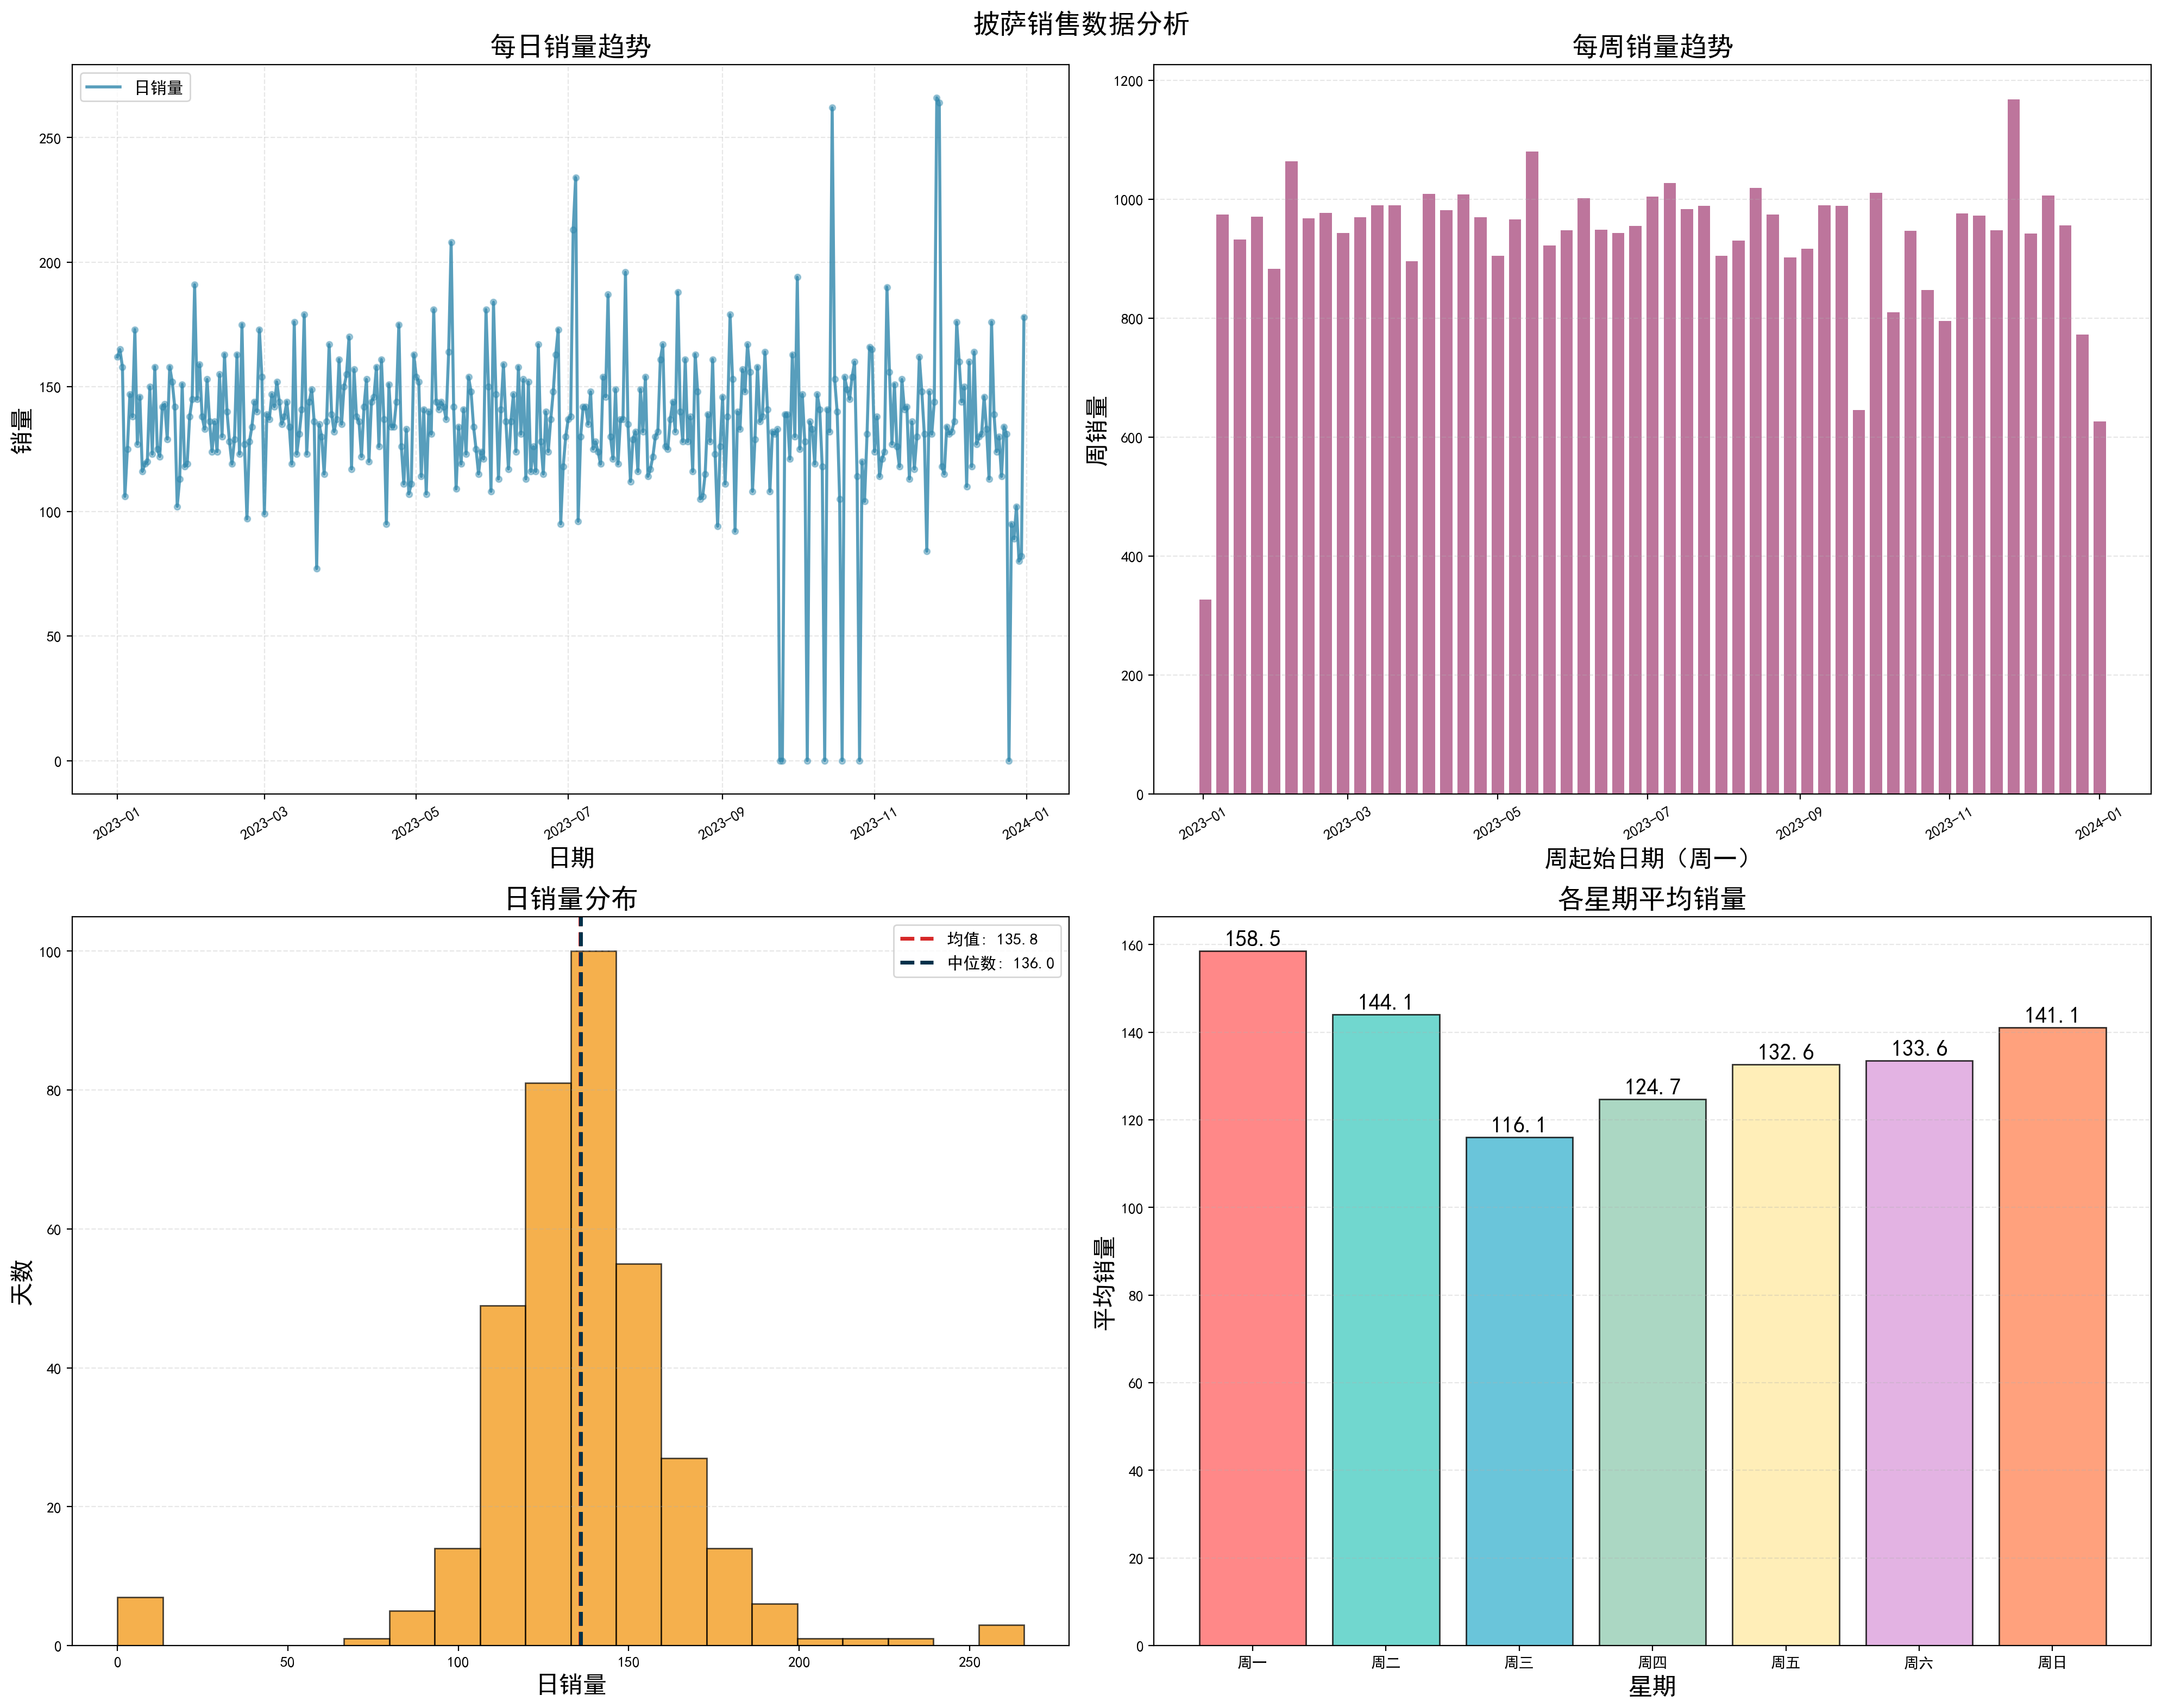

In [50]:
#画销售趋势图
fig, axes = plt.subplots(2, 2, figsize=(20, 16),dpi=200)
fig.suptitle('披萨销售数据分析', fontsize=18, fontweight='bold')

#每日销量趋势
ax1 = axes[0, 0]
ax1.plot(daily_sales['date'], daily_sales['total_quantity'], color='#2E86AB', linewidth=2, alpha=0.8)
ax1.scatter(daily_sales['date'], daily_sales['total_quantity'], color='#2E86AB', s=15, alpha=0.4, zorder=5)
ax1.set_title('每日销量趋势', fontsize=18, fontweight='bold')
ax1.set_xlabel('日期', fontsize=16)
ax1.set_ylabel('销量', fontsize=16)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(['日销量'], loc='upper left', fontsize=11)
ax1.tick_params(axis='x', rotation=30)

#周销量
weekly_sales = daily_sales.set_index('date')['total_quantity'].resample('W-Mon').sum().reset_index()
weekly_sales.columns = ['week_start', 'weekly_quantity']
ax2 = axes[0, 1]
bars = ax2.bar(weekly_sales['week_start'], weekly_sales['weekly_quantity'], color='#A23B72', alpha=0.7, width=5)
ax2.set_title('每周销量趋势', fontsize=18, fontweight='bold')
ax2.set_xlabel('周起始日期（周一）', fontsize=16)
ax2.set_ylabel('周销量', fontsize=16)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2.tick_params(axis='x', rotation=30)

#日销量分布直方图
ax3 = axes[1, 0]
ax3.hist(daily_sales['total_quantity'], bins=20, color='#F18F01', alpha=0.7, edgecolor='black', linewidth=1)
ax3.axvline(daily_sales['total_quantity'].mean(), color='#D62828', linestyle='--', 
            linewidth=2.5, label=f'均值: {daily_sales["total_quantity"].mean():.1f}')
ax3.axvline(daily_sales['total_quantity'].median(), color='#003049', linestyle='--', 
            linewidth=2.5, label=f'中位数: {daily_sales["total_quantity"].median():.1f}')
ax3.set_title('日销量分布', fontsize=18, fontweight='bold')
ax3.set_xlabel('日销量', fontsize=16)
ax3.set_ylabel('天数', fontsize=16)
ax3.legend(loc='upper right', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

#每周的均销量
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
day_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
weekday_avg = daily_sales.groupby('day_of_week')['total_quantity'].mean()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#FF8A5C']
ax4 = axes[1, 1]
bars2 = ax4.bar(day_names, weekday_avg, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax4.set_title('各星期平均销量', fontsize=18, fontweight='bold')
ax4.set_xlabel('星期', fontsize=16)
ax4.set_ylabel('平均销量', fontsize=16)
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

for i, (bar, val) in enumerate(zip(bars2, weekday_avg)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

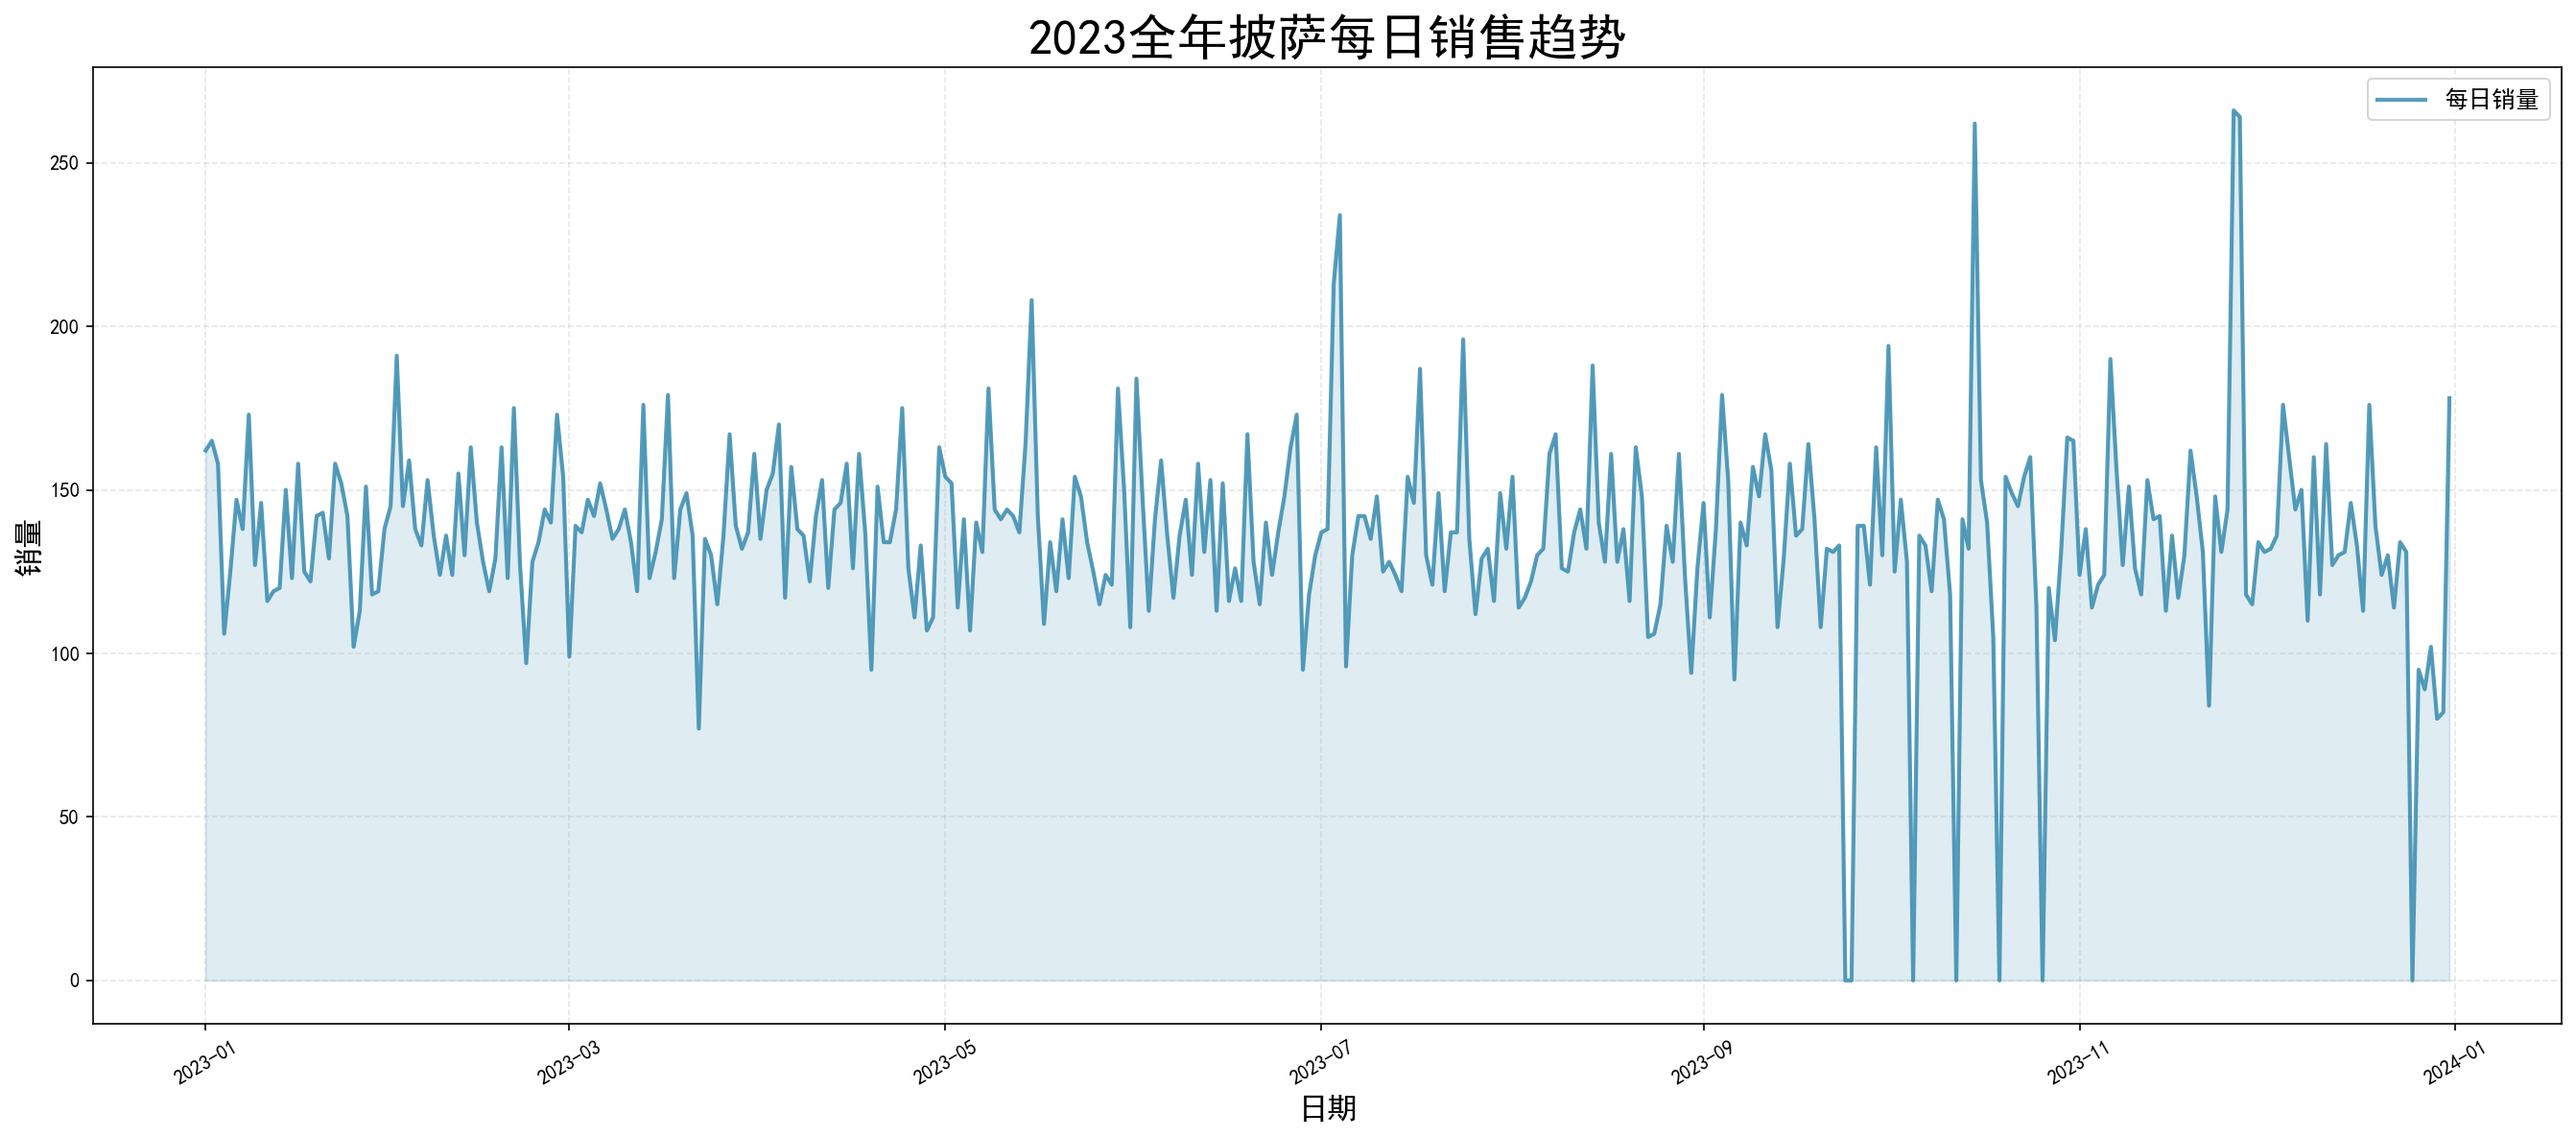

In [51]:
fig3, ax5 = plt.subplots(figsize=(18, 8),dpi=150)
ax5.plot(daily_sales['date'], daily_sales['total_quantity'], color='#2E86AB', linewidth=2, alpha=0.8, label='每日销量')
ax5.fill_between(daily_sales['date'], 0, daily_sales['total_quantity'], color='#2E86AB', alpha=0.15)
ax5.set_title('2023全年披萨每日销售趋势', fontsize=25, fontweight='bold')
ax5.set_xlabel('日期', fontsize=15)
ax5.set_ylabel('销量', fontsize=15)
ax5.legend(loc=1, fontsize=12)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

每月销售量统计
year_month  total_quantity       date
   2023-01            4232 2023-01-01
   2023-02            3961 2023-02-01
   2023-03            4261 2023-03-01
   2023-04            4151 2023-04-01
   2023-05            4328 2023-05-01
   2023-06            4107 2023-06-01
   2023-07            4392 2023-07-01
   2023-08            4168 2023-08-01
   2023-09            3890 2023-09-01
   2023-10            3883 2023-10-01
   2023-11            4266 2023-11-01
   2023-12            3935 2023-12-01


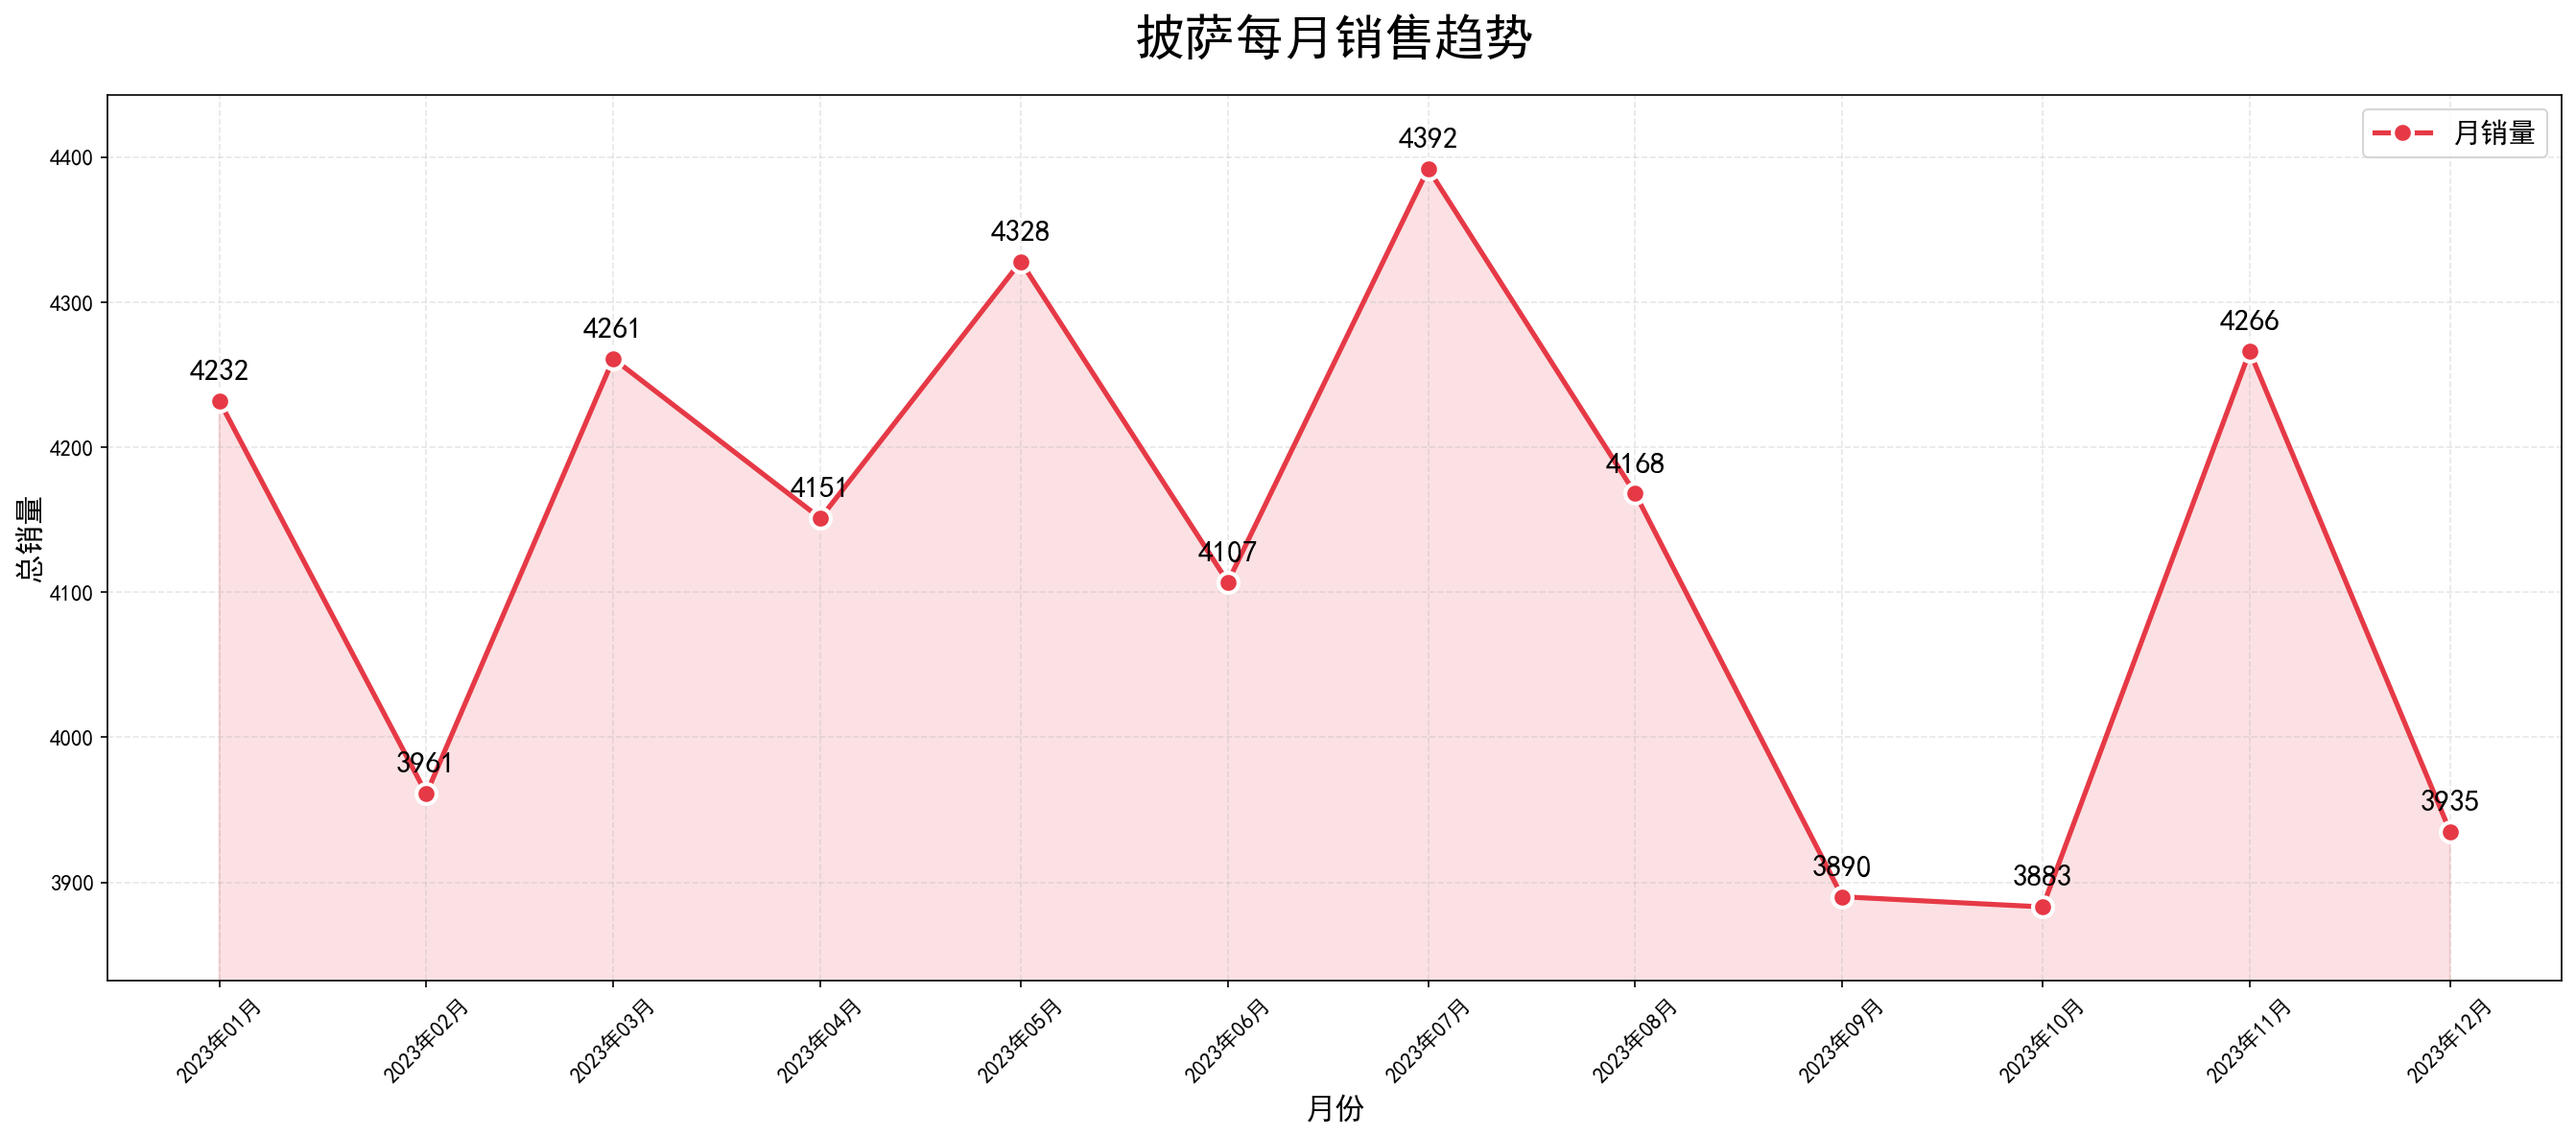

月度销售统计汇总
总月份数: 12
总销量: 49574
月均销量: 4131.17
最高月销量: 4392 (2023-07)
最低月销量: 3883 (2023-10)


In [40]:
#计算每月销售量
df['year_month'] = pd.to_datetime(df['order_date']).dt.to_period('M')

monthly_sales = df.groupby('year_month')['quantity'].sum().reset_index()
monthly_sales.columns = ['year_month', 'total_quantity']
monthly_sales['date'] = monthly_sales['year_month'].dt.to_timestamp()

print("每月销售量统计")
print(monthly_sales.to_string(index=False))

#每月销售量折线图
fig, ax = plt.subplots(figsize=(18, 8),dpi=150)

ax.plot(monthly_sales['date'], monthly_sales['total_quantity'], marker='o', linewidth=2.5, markersize=10, color='#E63946', 
        label='月销量', markeredgecolor='white', markeredgewidth=2)

for i, (x, y) in enumerate(zip(monthly_sales['date'], monthly_sales['total_quantity'])):
    ax.annotate(f'{y}', 
                (x, y), 
                textcoords="offset points", 
                xytext=(0, 10), 
                ha='center', 
                fontsize=15,
                fontweight='bold',
                color='#000000')

ax.fill_between(monthly_sales['date'], 0, monthly_sales['total_quantity'], color='#E63946', alpha=0.15)

ax.set_title('披萨每月销售趋势', fontsize=25, fontweight='bold', pad=20)
ax.set_xlabel('月份', fontsize=15)
ax.set_ylabel('总销量', fontsize=15)


ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y年%m月'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

ax.legend(loc=1, fontsize=14)

min_val = monthly_sales['total_quantity'].min()
max_val = monthly_sales['total_quantity'].max()
padding = (max_val - min_val) * 0.1
ax.set_ylim(min_val - padding, max_val + padding)

plt.tight_layout()
plt.show()

#汇总
print("月度销售统计汇总")
print(f"总月份数: {len(monthly_sales)}")
print(f"总销量: {monthly_sales['total_quantity'].sum()}")
print(f"月均销量: {monthly_sales['total_quantity'].mean():.2f}")
print(f"最高月销量: {monthly_sales['total_quantity'].max()} ({monthly_sales[monthly_sales['total_quantity'] == monthly_sales['total_quantity'].max()]['year_month'].iloc[0]})")
print(f"最低月销量: {monthly_sales['total_quantity'].min()} ({monthly_sales[monthly_sales['total_quantity'] == monthly_sales['total_quantity'].min()]['year_month'].iloc[0]})")


每小时销售量统计:
    hour  total_quantity
0      9               4
1     10              18
2     11            2728
3     12            6776
4     13            6413
5     14            3613
6     15            3216
7     16            4239
8     17            5211
9     18            5417
10    19            4406
11    20            3534
12    21            2545
13    22            1386
14    23              68


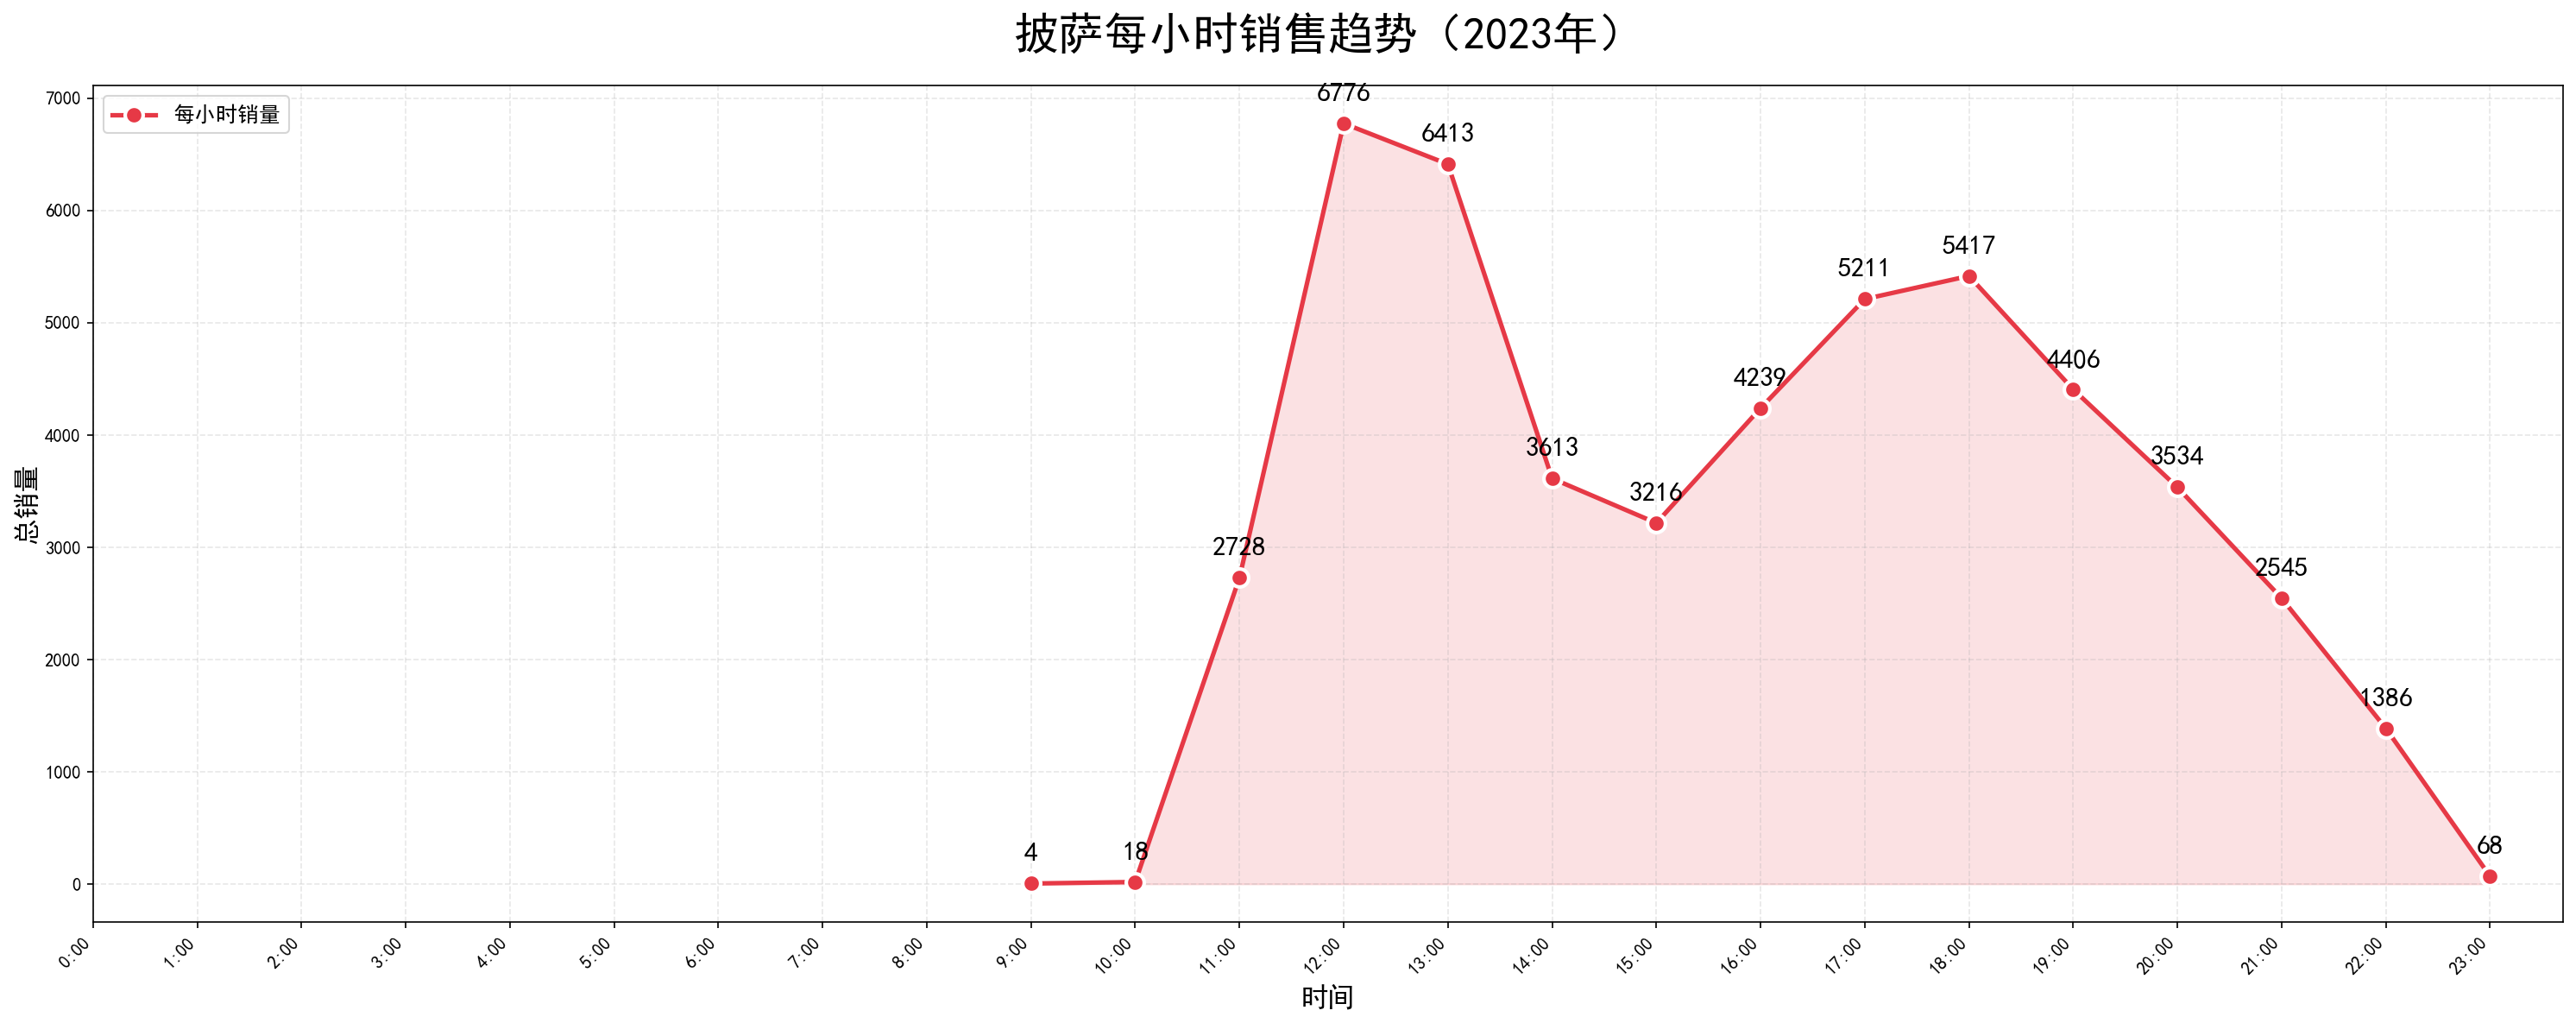

In [47]:
#计算每小时销量
df['hour'] = pd.to_datetime(df['order_time'], format='%H:%M:%S').dt.hour

#按小时汇总销量
hourly_sales = df.groupby('hour')['quantity'].sum().reset_index()
hourly_sales.columns = ['hour', 'total_quantity']

print("每小时销售量统计:")
print(hourly_sales)

#画每小时销量趋势图
fig, ax = plt.subplots(figsize=(20, 8),dpi=150)

ax.plot(hourly_sales['hour'], hourly_sales['total_quantity'],marker='o', linewidth=2.5, markersize=10,color='#E63946', label='每小时销量', 
        markeredgecolor='white', markeredgewidth=2)

for i, row in hourly_sales.iterrows():
    ax.annotate(f'{row["total_quantity"]}', 
                (row['hour'], row['total_quantity']), 
                textcoords="offset points", 
                xytext=(0, 12), 
                ha='center', 
                fontsize=15,
                fontweight='bold',
                color='#000000')

ax.fill_between(hourly_sales['hour'], 0, hourly_sales['total_quantity'],color='#E63946', alpha=0.15)

ax.set_title('披萨每小时销售趋势（2023年）', fontsize=25, fontweight='bold', pad=20)
ax.set_xlabel('时间', fontsize=15)
ax.set_ylabel('总销量', fontsize=15)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{i}:00' for i in range(24)], rotation=45, ha='right')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(loc=2, fontsize=12)

plt.tight_layout()
plt.show()

In [42]:
# 自动ARIMA建模
model = pm.auto_arima(
    series,
    start_p=0, max_p=5,
    start_d=0, max_d=2,
    start_q=0, max_q=5,
    seasonal=True, m=7,          
    start_P=0, max_P=2,
    start_D=0, max_D=1,
    start_Q=0, max_Q=2,
    trace=False,                
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic')

print("最优模型参数:", model.order)
print("季节性参数:", model.seasonal_order)

#预测未来28天
forecast_steps = 28
forecast, conf_int = model.predict(n_periods=forecast_steps, return_conf_int=True)

last_date = daily_sales['date'].max()
start_date = pd.to_datetime("2024-01-01")
pred_dates = pd.date_range(start=start_date, periods=forecast_steps, freq='D')

#构建预测结果df
pred_df = pd.DataFrame({'date': pred_dates,'predicted_quantity': forecast,'lower_bound': conf_int[:, 0],
    'upper_bound': conf_int[:, 1]})
print("预测结果（2024年1月1日到1月28日）:")
pred_df

最优模型参数: (1, 0, 0)
季节性参数: (2, 0, 0, 7)
预测结果（2024年1月1日到1月28日）:


,date,predicted_quantity,lower_bound,upper_bound
0,2024-01-01,115.807071,61.075527,170.538616
1,2024-01-02,126.825099,71.073670,182.576528
2,2024-01-03,120.733743,64.944314,176.523172
3,2024-01-04,125.194484,69.403626,180.985343
4,2024-01-05,115.945118,60.154206,171.736030
5,2024-01-06,120.463465,64.672551,176.254379
6,2024-01-07,146.080441,90.289527,201.871355
7,2024-01-08,103.008126,45.249644,160.766608
8,2024-01-09,124.935540,67.104353,182.766727
9,2024-01-10,122.077188,64.243267,179.911108


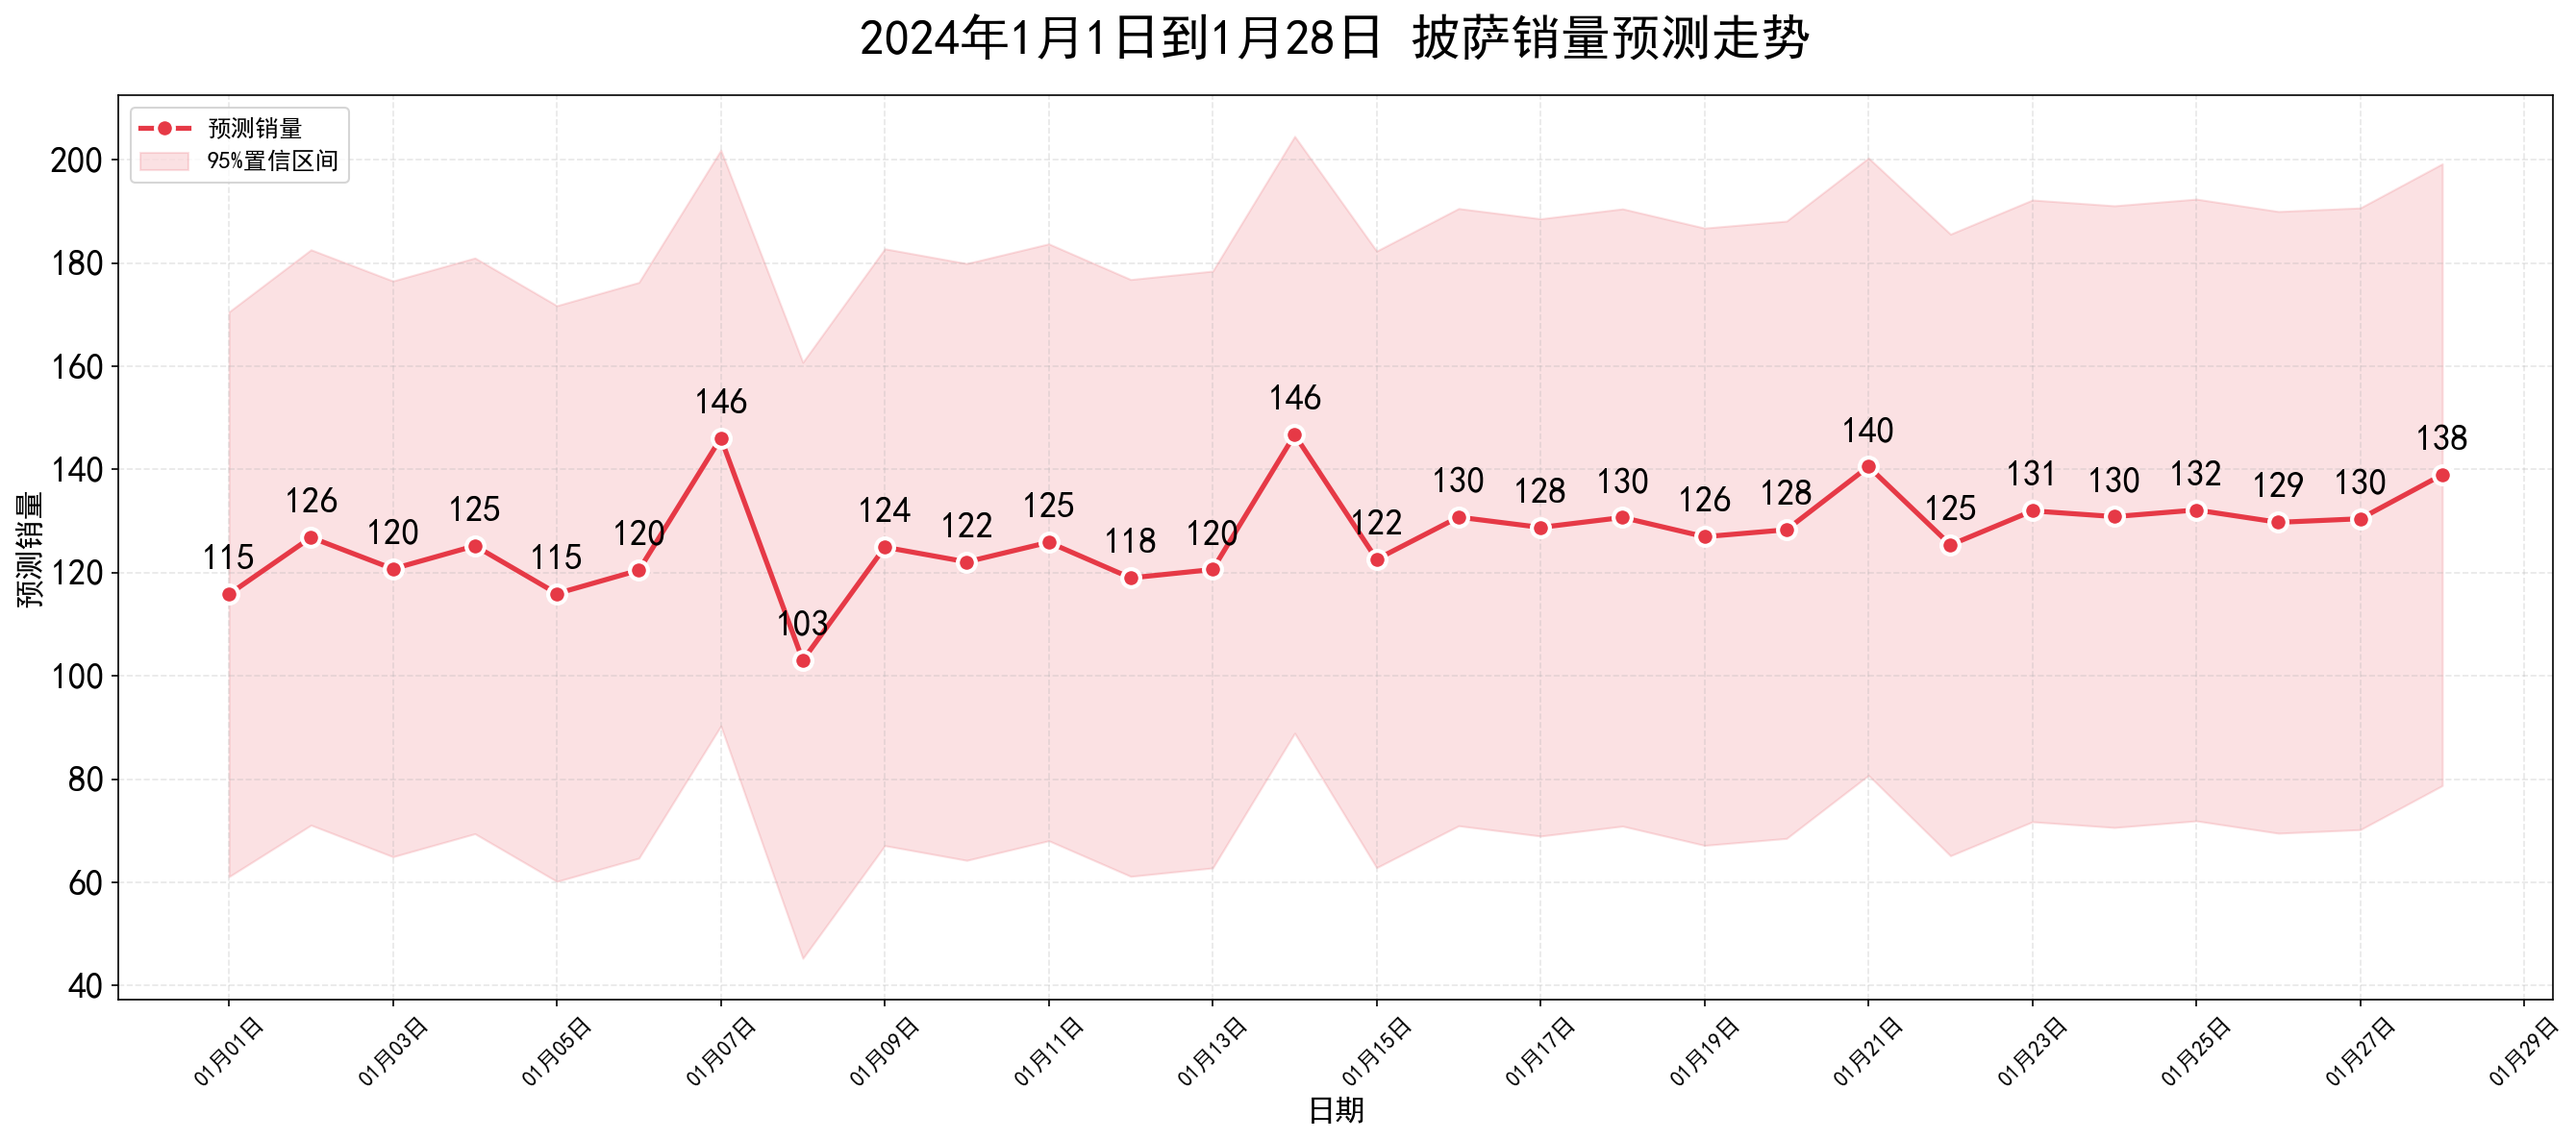

        日期  预测销量  下限  上限
2024-01-01   115  61 170
2024-01-02   126  71 182
2024-01-03   120  64 176
2024-01-04   125  69 180
2024-01-05   115  60 171
2024-01-06   120  64 176
2024-01-07   146  90 201
2024-01-08   103  45 160
2024-01-09   124  67 182
2024-01-10   122  64 179
2024-01-11   125  68 183
2024-01-12   118  61 176
2024-01-13   120  62 178
2024-01-14   146  88 204
2024-01-15   122  62 182
2024-01-16   130  70 190
2024-01-17   128  68 188
2024-01-18   130  70 190
2024-01-19   126  67 186
2024-01-20   128  68 188
2024-01-21   140  80 200
2024-01-22   125  65 185
2024-01-23   131  71 192
2024-01-24   130  70 191
2024-01-25   132  71 192
2024-01-26   129  69 189
2024-01-27   130  70 190
2024-01-28   138  78 199

预测总销量: 3561
日均预测销量: 127.19
最高预测日: 2024-01-14 (146)
最低预测日: 2024-01-08 (103)


In [49]:
pred_dates = pd.date_range(start="2024-01-01", periods=forecast_steps, freq='D')

#画预测走势图
fig, ax = plt.subplots(figsize=(18, 8),dpi=150)

ax.plot(pred_dates, forecast, marker='o', linewidth=2.5, markersize=9, color='#E63946', label='预测销量',
        markeredgecolor='white', markeredgewidth=2)

for i, (date, val) in enumerate(zip(pred_dates, forecast)):
    ax.annotate(f'{int(val)}', 
                (date, val), 
                textcoords="offset points", 
                xytext=(0, 12), 
                ha='center', 
                fontsize=18,
                fontweight='bold',
                color='black')

ax.fill_between(pred_dates, conf_int[:, 0], conf_int[:, 1], color='#E63946', alpha=0.15, label='95%置信区间')

ax.set_title('2024年1月1日到1月28日 披萨销量预测走势',fontsize=25, fontweight='bold', pad=20)
ax.set_xlabel('日期', fontsize=15)
ax.set_ylabel('预测销量', fontsize=15)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%m月%d日'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=18)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(loc=2, fontsize=12)

plt.tight_layout()
plt.show()

#预测结果分析
pred_df = pd.DataFrame({'日期': pred_dates.strftime('%Y-%m-%d'),'预测销量': forecast.astype(int),'下限': conf_int[:, 0].astype(int),
    '上限': conf_int[:, 1].astype(int)})
print(pred_df.to_string(index=False))

print(f"\n预测总销量: {int(forecast.sum())}")
print(f"日均预测销量: {forecast.mean():.2f}")
print(f"最高预测日: {pred_dates[forecast.argmax()].strftime('%Y-%m-%d')} ({int(forecast.max())})")
print(f"最低预测日: {pred_dates[forecast.argmin()].strftime('%Y-%m-%d')} ({int(forecast.min())})")

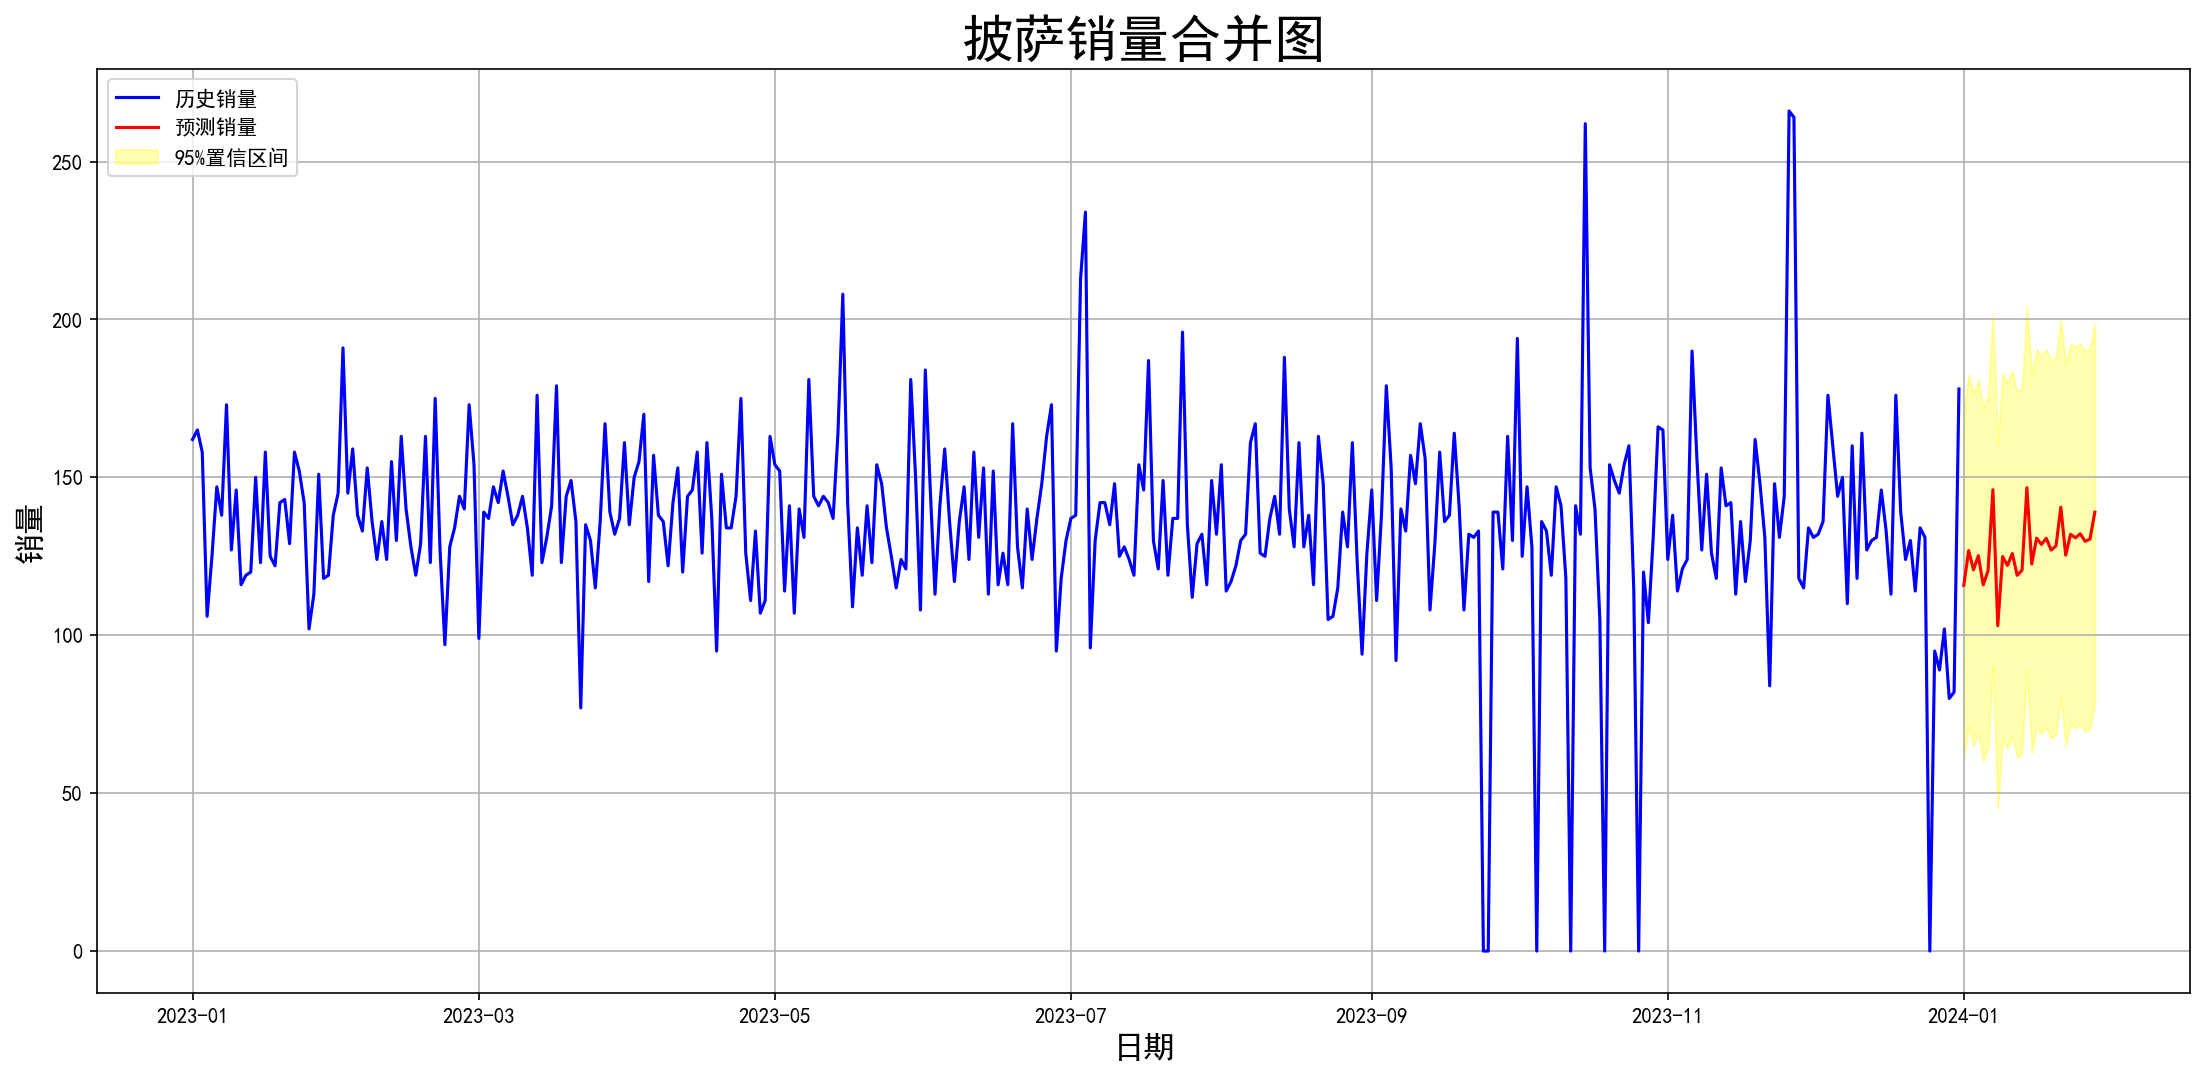

In [52]:
#整体合并销量趋势图
plt.figure(figsize=(18, 8),dpi=150)
plt.plot(dates, series, label='历史销量', color='blue')
plt.plot(pred_dates, forecast, label='预测销量', color='red')
plt.fill_between(pred_dates, conf_int[:, 0], conf_int[:, 1], color='yellow', alpha=0.3, label='95%置信区间')
plt.title('披萨销量合并图',fontsize=25)
plt.xlabel('日期',fontsize=15)
plt.ylabel('销量',fontsize=15)
plt.legend(loc=2)
plt.grid(True)
plt.show()